In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import time
start_time = time.time()


gas_mix_incomplete = ct.Solution('gri30.yaml')

In [ ]:
T_0 = 298 # K
p = ct.one_atm

vel_list = []

phi_begin = 0.5
phi_end = 1.8
N = 20
phi_list = [phi_begin + (phi_end-phi_begin) * (n/(N-1) + np.sin(2*np.pi*n/(N-1))/(2*np.pi)) for n in range(N)]

for j, phi in enumerate(phi_list):
    # Contador j no se usa
    print(f"\033[1;36m### EQUIVALENCE RATIO: {phi} ###\033[0m")

    gas_mix_incomplete.TP = T_0, p
    gas_mix_incomplete.set_equivalence_ratio(phi, 'CH4', 'O2: 1.0, N2: 3.76')

    # Llama
    flame = ct.FreeFlame(gas=gas_mix_incomplete, width=0.03)
        # Clase FreeFlame --> llama de premezcla 1D
        # width crea grid en intervalo [0,width]
        # y que solver determine ptos. intermedios.

    flame.set_refine_criteria(ratio=3, slope=0.06, curve=0.12)
        # Criterios que solver seguirá para refinar grid.
        # Por ejemplo, slope dice que si dif. máx de valores en nodos adyacentes
        # supera el 6% de la máx diferencia del perfil, añade puntos intermedios.
    # print(flame.grid)

    if phi != phi_begin:
        flame.set_initial_guess(data=flame_sol_previa)
        # Uso solución de llama con el phi anterior como punto de partida para este
        # Opcional. Tiempo cómputo se reduce 49%.

    flame.solve(loglevel=1, refine_grid=True, auto=True)
        # Método del objeto flame que resuelve ecs. de fluidos en dif. finitas.
    flame_sol_previa = flame.to_array()
        # Guardo la solución de un bucle en esta variable.

    print(f"\033[1;36m### LAMINAR BURNING SPEED: {flame.velocity[0]*100} cm/s ###\033[0m")

    vel_list.append(flame.velocity[0] * 100) # cm/s
        # flame.velocity[0] = velocidad en primer grid point (inlet).
    print("Run time %s seconds ---" % (time.time() - start_time))

print("Complete run time --- %s seconds ---" % (time.time() - start_time))

### EQUIVALENCE RATIO: 0.5 ###

************ Solving on 8 point grid with energy equation enabled ************

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0001709  log(ss)= 3.534     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.004379   log(ss)= 3.397     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.04988    log(ss)= 2.042     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.8522     log(ss)= 0.08346   

Attempt Newton solution of steady-state problem.
Newton steady-state solve succeeded.

Problem solved on [9] point grid(s).
Expanding domain to accommodate flame thickness. New width: 0.06 m
#############################################

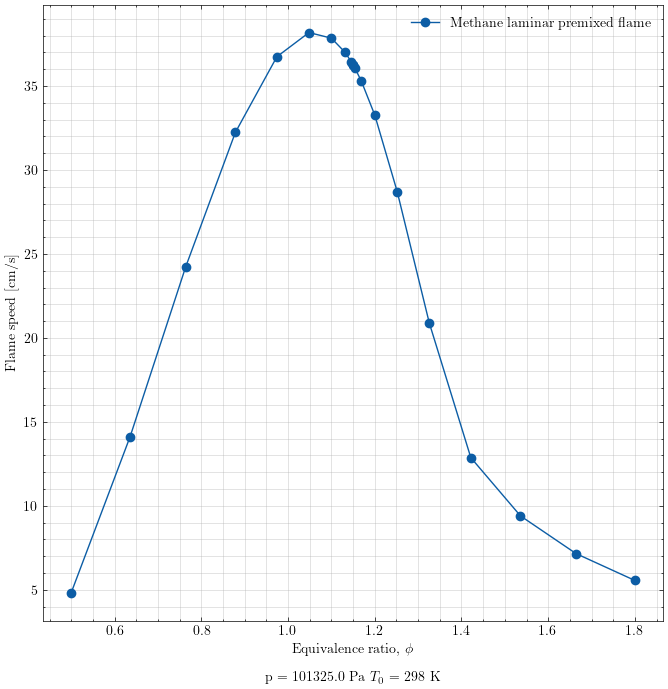

In [ ]:
plt.figure(figsize=(8,8))

plt.plot(phi_list,
        vel_list,
        label="Methane laminar premixed flame",
        marker="o")

plt.grid(True, which='both', alpha=0.5)

plt.xlabel("Equivalence ratio, "+ r"$\phi$"+ f"\n \n p = {p} Pa    $T_{{0}}$ = {T_0} K")
plt.ylabel("Flame speed [cm/s]")

plt.legend(loc='best', fontsize=10)

plt.savefig("S_vs_phi.svg")
plt.show()